In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
spectrum_1_HA = pd.read_csv("Spectrum1s_1_noreg_gas_exp.csv")
spectrum_1_HA = spectrum_1_HA.set_index('Name')
#spectrum_2 = pd.read_csv("Spectrum1s_2_noreg_gas_exp.csv")
#spectrum_2 = spectrum_2.set_index('Name')
spectrum_3_HA = pd.read_csv("Spectrum1s_3_noreg_gas_exp.csv")
spectrum_3_HA = spectrum_3_HA.set_index('Name')
spectrum_4_HA = pd.read_csv("Spectrum1s_4_noreg_gas_exp.csv")
spectrum_4_HA = spectrum_4_HA.set_index('Name')
spectrum_5_HA = pd.read_csv("Spectrum1s_5_noreg_gas_exp.csv")
spectrum_5_HA = spectrum_5_HA.set_index('Name')
spectrum_6_HA = pd.read_csv("Spectrum1s_6_noreg_gas_exp.csv")
spectrum_6_HA = spectrum_6_HA.set_index('Name')

spectrum_1_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Spectra_extraction/OIII_ext/1Sigma/Spectrum1s_1_noreg_gas_exp.csv")
spectrum_1_OIII = spectrum_1_OIII.set_index('Name')
#spectrum_2 = pd.read_csv("Spectrum1s_2_noreg_gas_exp.csv")
#spectrum_2 = spectrum_2.set_index('Name')
spectrum_3_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Spectra_extraction/OIII_ext/1Sigma/Spectrum1s_3_noreg_gas_exp.csv")
spectrum_3_OIII = spectrum_3_OIII.set_index('Name')
spectrum_4_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Spectra_extraction/OIII_ext/1Sigma/Spectrum1s_4_noreg_gas_exp.csv")
spectrum_4_OIII = spectrum_4_OIII.set_index('Name')
spectrum_5_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Spectra_extraction/OIII_ext/1Sigma/Spectrum1s_5_noreg_gas_exp.csv")
spectrum_5_OIII = spectrum_5_OIII.set_index('Name')
spectrum_6_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Spectra_extraction/OIII_ext/1Sigma/Spectrum1s_6_noreg_gas_exp.csv")
spectrum_6_OIII = spectrum_6_OIII.set_index('Name')

SNR_HA = pd.read_csv("SNR_HA_1s.csv")
SNR_OI = pd.read_csv("SNR_OI_1s.csv")
SNR_HB = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Spectra_extraction/OIII_ext/1Sigma/SNR_HB_1s.csv") 
SNR_NII_2 = pd.read_csv("SNR_NII_2_1s.csv") 
SNR_OIII_2 = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Spectra_extraction/OIII_ext/1Sigma/SNR_OIII_2_1s.csv") 
SNR_SII_1 = pd.read_csv("SNR_SII_1_1s.csv") 

In [4]:
def merge_spectral_data(df1, df2):
    """
    Sostituisce i dati di Hbeta e OIII in df2 con quelli di df1.
    
    Parameters:
    df1: DataFrame sorgente (da cui prendere i dati)
    df2: DataFrame destinazione (dove sostituire i dati)
    
    Returns:
    DataFrame risultante con i dati sostituiti
    """
    # Crea una copia di df2 per non modificare l'originale
    df_result = df2.copy()
    
    # Lista delle righe da sostituire
    righe_da_sostituire = ['Hbeta', '[OIII]4959', '[OIII]5007']
    
    # Per ogni riga da sostituire
    for nome_riga in righe_da_sostituire:
        # Cerca la riga in df1 (usa l'indice se 'Name' è l'indice)
        if nome_riga in df1.index:
            riga_df1 = df1.loc[nome_riga]
            
            # Cerca la riga in df2
            if nome_riga in df_result.index:
                # Sostituisci i valori di Flux e Error_flux
                df_result.loc[nome_riga, 'Flux'] = riga_df1['Flux']
                df_result.loc[nome_riga, 'Error_flux'] = riga_df1['Error_flux']
                print(f"✓ Sostituito: {nome_riga}")
            else:
                print(f"Attenzione: {nome_riga} non trovato in df2")
        else:
            print(f"Attenzione: {nome_riga} non trovato in df1")
    
    return df_result

spectrum_1 = merge_spectral_data(spectrum_1_OIII, spectrum_1_HA)
spectrum_3 = merge_spectral_data(spectrum_3_OIII, spectrum_3_HA)
spectrum_4 = merge_spectral_data(spectrum_4_OIII, spectrum_4_HA)
spectrum_5 = merge_spectral_data(spectrum_5_OIII, spectrum_5_HA)
spectrum_6 = merge_spectral_data(spectrum_6_OIII, spectrum_6_HA)

✓ Sostituito: Hbeta
✓ Sostituito: [OIII]4959
✓ Sostituito: [OIII]5007
✓ Sostituito: Hbeta
✓ Sostituito: [OIII]4959
✓ Sostituito: [OIII]5007
✓ Sostituito: Hbeta
✓ Sostituito: [OIII]4959
✓ Sostituito: [OIII]5007
✓ Sostituito: Hbeta
✓ Sostituito: [OIII]4959
✓ Sostituito: [OIII]5007
✓ Sostituito: Hbeta
✓ Sostituito: [OIII]4959
✓ Sostituito: [OIII]5007


In [5]:
def Ku03(x):
    # AGN selection based on Kauffman et al. 2003
    # log OIII/Hb > 0.61/(log NII/Ha - 0.05) + 1.3
    return 0.61/(x - 0.05) + 1.3

def Ke01(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.61/(log NII/Ha - 0.47) + 1.19
     return 0.61/(x - 0.47) + 1.19

def S06(x):
    # AGN selection based on Stasinska et al 2006
     # log OIII/Hb > 0.29/(log NII/Ha +0.20) + 0.96
    return 0.29/(x + 0.20) + 0.96

def C10(x):
 # Seyfert–LINER line based on Cid Fernandes et al 2010
    return 1.01*x + 0.48

def Ke01_SII(x):
     # AGN selection based on Kewley et al. 2001
     # log OIII/Hb > 0.72/(log SII/Ha - 0.32) + 1.3
     return 0.72/(x - 0.32) + 1.3

def Ke06(x):
    #Seyfert–LINER line
    return 1.89* x + 0.76

def Ke_OI(x):
    return 0.73/(x + 0.59) + 1.33

def error_ratio(err_1, err_2, flux_1, flux_2):
    e_1 = err_1/(flux_1*np.log(10))
    e_2 = err_2/(flux_2*np.log(10))
    print(np.sqrt((e_1)**2+(e_2)**2))
    return np.sqrt((e_1)**2+(e_2)**2)

def ratio(spectrum):
    OIII_HB = spectrum.loc['[OIII]5007', 'Flux']/spectrum.loc['Hbeta', 'Flux']
    NII_HA = spectrum.loc['[NII]6583', 'Flux']/spectrum.loc['Halpha', 'Flux']
    SII_HA = spectrum.loc['[SII]6716', 'Flux']/spectrum.loc['Halpha', 'Flux']
    OI_HA = spectrum.loc['[OI]6300', 'Flux']/spectrum.loc['Halpha', 'Flux']
    err_OIII_HB = error_ratio(spectrum.loc['[OIII]5007', 'Error_flux'], spectrum.loc['Hbeta', 'Error_flux'], spectrum.loc['[OIII]5007', 'Flux'], spectrum.loc['Hbeta', 'Flux'])
    err_NII_HA = error_ratio(spectrum.loc['[NII]6583', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[NII]6583', 'Flux'], spectrum.loc['Halpha', 'Flux'])
    err_SII_HA = error_ratio(spectrum.loc['[SII]6716', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[SII]6716', 'Flux'], spectrum.loc['Halpha', 'Flux']) 
    err_OI_HA = error_ratio(spectrum.loc['[OI]6300', 'Error_flux'], spectrum.loc['Halpha', 'Error_flux'], spectrum.loc['[OI]6300', 'Flux'], spectrum.loc['Halpha', 'Flux']) 
    return OIII_HB, NII_HA, SII_HA, OI_HA, err_OIII_HB, err_NII_HA, err_SII_HA, err_OI_HA

def evaluation_SNR(SNR_HA, SNR_HB, SNR_NII, SNR_SII, SNR_OIII):
    if (SNR_HB < 0) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        print('HB<0 but OIII>3')
        return True 
    elif (SNR_HB >= 3) and (SNR_OIII >= 3) and (SNR_HA >= 3) and (SNR_NII >= 3) and (SNR_SII >= 3):
        print('All ok')
        return True 
    else: 
        print('False')
        return False 

In [6]:
for i in range(6):
    print(i+1)
    evaluation_SNR(SNR_HA['SNR'][i], SNR_HB['SNR'][i], SNR_NII_2['SNR'][i], SNR_SII_1['SNR'][i], SNR_OIII_2['SNR'][i])
for i in range(6):
    if SNR_OI['SNR'][i] >= 3:
        print(i+1, 'SNR(OI) ok')

1
All ok
2
False
3
All ok
4
All ok
5
All ok
6
All ok
1 SNR(OI) ok
3 SNR(OI) ok
4 SNR(OI) ok
5 SNR(OI) ok
6 SNR(OI) ok


0.031496577595176524
0.03362764310743869
0.022855808868303948
0.04922503107811664
0.053326293549893385
0.007121584229022048
0.012429442894445206
0.06301850855720179
0.05291658245308749
0.01133975309667405
0.014142630580389882
0.05088082412857604
0.04985819885698412
0.008714069688952839
0.005792765928147295
0.04522217738652781
0.04995856018323595
0.03949044072056997
0.017300304981633964
0.1439621920565414


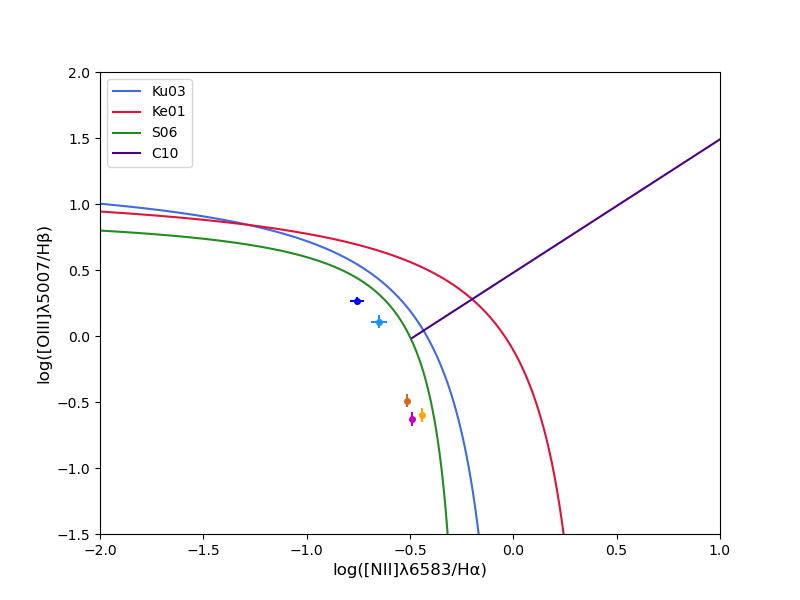

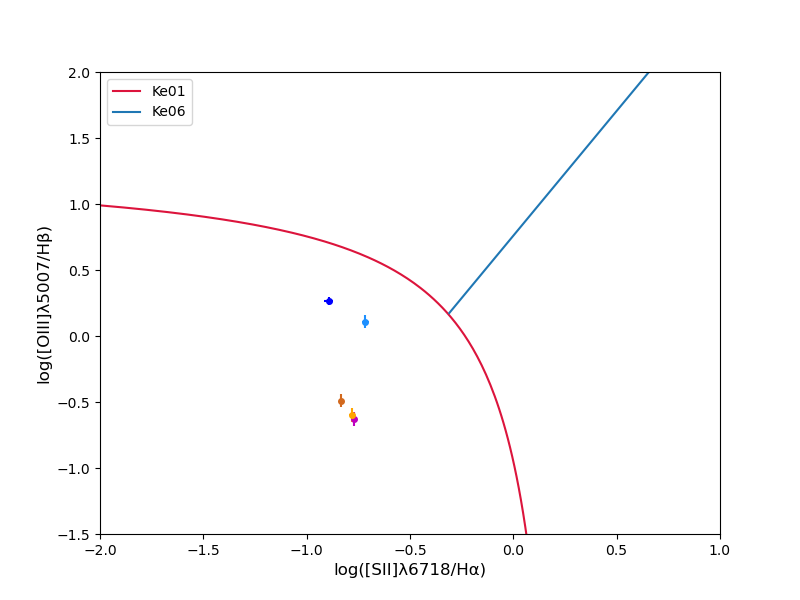

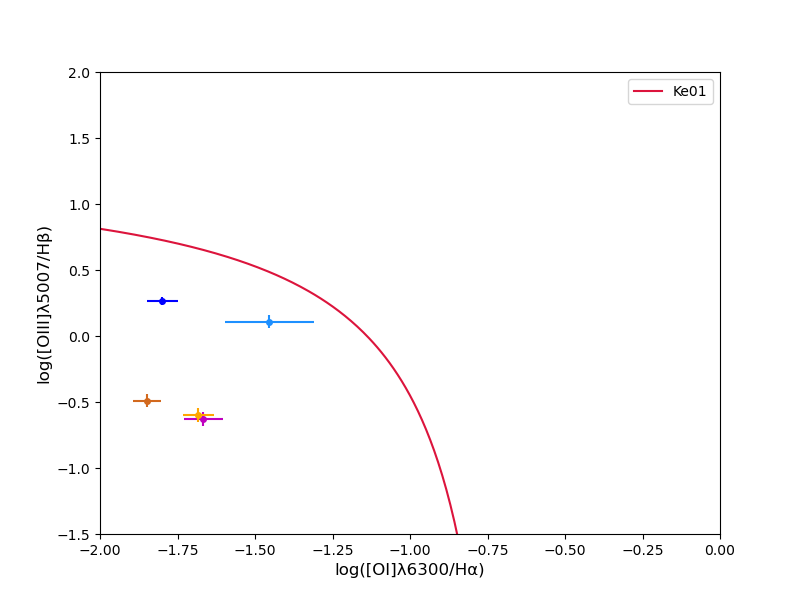

In [11]:
plt.figure(figsize=(8,6))

OIII_HB_1, NII_HA_1, SII_HA_1, OI_HA_1, err_OIII_HB_1, err_NII_HA_1, err_SII_HA_1, err_OI_HA_1 = ratio(spectrum_1)
#OIII_HB_2, NII_HA_2, SII_HA_2, err_OIII_HB_2, err_NII_HA_2, err_SII_HA_2 = ratio(spectrum_2)
OIII_HB_3, NII_HA_3, SII_HA_3, OI_HA_3, err_OIII_HB_3, err_NII_HA_3, err_SII_HA_3, err_OI_HA_3 = ratio(spectrum_3)
OIII_HB_4, NII_HA_4, SII_HA_4, OI_HA_4, err_OIII_HB_4, err_NII_HA_4, err_SII_HA_4, err_OI_HA_4 = ratio(spectrum_4)
OIII_HB_5, NII_HA_5, SII_HA_5, OI_HA_5, err_OIII_HB_5, err_NII_HA_5, err_SII_HA_5, err_OI_HA_5= ratio(spectrum_5)
OIII_HB_6, NII_HA_6, SII_HA_6, OI_HA_6, err_OIII_HB_6, err_NII_HA_6, err_SII_HA_6, err_OI_HA_6 = ratio(spectrum_6)

plt.errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_5), y =np.log10(OIII_HB_5), xerr = err_NII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_6), y =np.log10(OIII_HB_6), xerr = err_NII_HA_6, yerr = err_OIII_HB_6,  color = 'dodgerblue', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
plt.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
plt.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
plt.plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
plt.plot(x3, C10(x3), label = 'C10', color = 'indigo')
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_1s', bbox_inches='tight')

plt.figure(figsize=(8,6))

plt.errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_4), y = np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_5), y =np.log10(OIII_HB_5), xerr = err_SII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_6), y =np.log10(OIII_HB_6), xerr = err_SII_HA_6, yerr = err_OIII_HB_6,  color = 'dodgerblue', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_1s', bbox_inches='tight')

plt.figure(figsize=(8,6))

plt.errorbar(x = np.log10(OI_HA_1), y = np.log10(OIII_HB_1), xerr = err_OI_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(OI_HA_3), y = np.log10(OIII_HB_3), xerr = err_OI_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(OI_HA_4), y = np.log10(OIII_HB_4), xerr = err_OI_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(OI_HA_5), y =np.log10(OIII_HB_5), xerr = err_OI_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(OI_HA_6), y =np.log10(OIII_HB_6), xerr = err_OI_HA_6, yerr = err_OIII_HB_6,  color = 'dodgerblue', markersize = 4, marker = 'o')

x = np.linspace(-2, -0.7, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke_OI(x), label = 'Ke01', color = 'crimson')
#plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-2, 0)
plt.ylim(-1.5, 2)
plt.xlabel('log([OI]λ6300/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_OI_1s', bbox_inches='tight')

## BPT con correzioni

In [43]:
areas_OIII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Contaminations/Areas_OIII_1s-OIII.csv",
                        index_col = 0)
areas_NII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Contaminations/Areas_NII_1s.csv",
                        index_col = 0)
areas_SII = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Contaminations/Areas_SII_1s.csv",
                        index_col = 0)
areas_Halpha = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Contaminations/Areas_Halpha_1s.csv",
                        index_col = 0)
areas_Hbeta = pd.read_csv("C:/Users/ISAFA/Desktop/Tesi magistrale/Sources/FIRSTJ110949/FIRSTJ110949_1/Contaminations/Areas_Hbeta_1s-OIII.csv",
                        index_col = 0)

In [44]:
def true_flux(spectrum1, spectrum3, spectrum4, spectrum5, spectrum6, area, e_1, e_3, e_4, e_5, e_6):
    riga_1 = spectrum1*area['Peak 1'].iloc[0]/100
    err_1 = riga_1*0.1
    
    #riga_2 = spectrum2 * area['Peak 2'].iloc[1]/100
   # err_2 = e_2 * area['Peak 2'].iloc[1]/100
    
    riga_3 = spectrum3 * area['Peak 3'].iloc[2]/100
    err_3 = riga_3*0.1
    
    riga_4 = spectrum4*area['Peak 4'].iloc[3]/100
    err_4 = riga_4*0.1
    
    riga_5 = spectrum5 * area['Peak 5'].iloc[4]/100
    err_5 = riga_5*0.1

    riga_6 = spectrum6 * area['Peak 6'].iloc[5]/100
    err_6 = riga_6*0.1
    return riga_1, riga_3, riga_4, riga_5, riga_6, err_1, err_3, err_4, err_5, err_6

def ratio_true(OIII, HB, HA, NII, SII, err_OIII, err_HB, err_HA, err_NII, err_SII):
    OIII_HB_true = OIII/HB
    NII_HA_true = NII/HA
    SII_HA_true = SII/HA
    err_OIII_HB_true = error_ratio(err_OIII, err_HB, OIII, HB)
    err_NII_HA_true = error_ratio(err_NII, err_HA, NII, HA)
    err_SII_HA_true = error_ratio(err_SII, err_HA, SII, HA)
    return OIII_HB_true, NII_HA_true, SII_HA_true, err_OIII_HB_true, err_SII_HA_true, err_NII_HA_true

In [45]:
OIII_1, OIII_3, OIII_4, OIII_5, OIII_6, err_OIII_1, err_OIII_3, err_OIII_4, err_OIII_5, err_OIII_6 = true_flux(spectrum_1.loc['[OIII]5007', 'Flux'], 
                                                                                           spectrum_3.loc['[OIII]5007', 'Flux'], spectrum_4.loc['[OIII]5007', 'Flux'], spectrum_5.loc['[OIII]5007', 'Flux'], spectrum_6.loc['[OIII]5007', 'Flux'],
                                                                                            areas_OIII, spectrum_1.loc['[OIII]5007', 'Error_flux'], 
                                                                                           spectrum_3.loc['[OIII]5007', 'Error_flux'], spectrum_4.loc['[OIII]5007', 'Error_flux'], 
                                                                                            spectrum_5.loc['[OIII]5007', 'Error_flux'], spectrum_6.loc['[OIII]5007', 'Error_flux'])
HB_1, HB_3, HB_4, HB_5, HB_6, err_HB_1, err_HB_3, err_HB_4, err_HB_5, err_HB_6 = true_flux(spectrum_1.loc['Hbeta', 'Flux'], 
                                                    spectrum_3.loc['Hbeta', 'Flux'], spectrum_4.loc['Hbeta', 'Flux'], spectrum_5.loc['Hbeta', 'Flux'], spectrum_6.loc['Hbeta', 'Flux'], areas_Hbeta,
                                                    spectrum_1.loc['Hbeta', 'Error_flux'], 
                                                    spectrum_3.loc['Hbeta', 'Error_flux'], spectrum_4.loc['Hbeta', 'Error_flux'], 
                                                    spectrum_5.loc['Hbeta', 'Error_flux'], spectrum_6.loc['Hbeta', 'Error_flux'])
HA_1, HA_3, HA_4, HA_5, HA_6, err_HA_1, err_HA_3, err_HA_4, err_HA_5, err_HA_6 = true_flux(spectrum_1.loc['Halpha', 'Flux'], 
                                                    spectrum_3.loc['Halpha', 'Flux'], spectrum_4.loc['Halpha', 'Flux'], spectrum_5.loc['Halpha', 'Flux'], spectrum_6.loc['Halpha', 'Flux'], areas_Halpha,
                                                    spectrum_1.loc['Halpha', 'Error_flux'], 
                                                    spectrum_3.loc['Halpha', 'Error_flux'], spectrum_4.loc['Halpha', 'Error_flux'], 
                                                    spectrum_5.loc['Halpha', 'Error_flux'], spectrum_6.loc['Halpha', 'Error_flux'])
NII_1, NII_3, NII_4, NII_5, NII_6, err_NII_1, err_NII_3, err_NII_4, err_NII_5, err_NII_6 = true_flux(spectrum_1.loc['[NII]6583', 'Flux'], 
                                                    spectrum_3.loc['[NII]6583', 'Flux'], spectrum_4.loc['[NII]6583', 'Flux'], spectrum_5.loc['[NII]6583', 'Flux'], spectrum_6.loc['[NII]6583', 'Flux'], areas_NII,
                                                    spectrum_1.loc['[NII]6583', 'Error_flux'], 
                                                    spectrum_3.loc['[NII]6583', 'Error_flux'], spectrum_4.loc['[NII]6583', 'Error_flux'], 
                                                    spectrum_5.loc['[NII]6583', 'Error_flux'], spectrum_6.loc['[NII]6583', 'Error_flux'])
SII_1, SII_3, SII_4, SII_5, SII_6, err_SII_1, err_SII_3, err_SII_4, err_SII_5, err_SII_6 = true_flux(spectrum_1.loc['[SII]6716', 'Flux'], 
                                                    spectrum_3.loc['[SII]6716', 'Flux'], spectrum_4.loc['[SII]6716', 'Flux'], spectrum_5.loc['[SII]6716', 'Flux'], spectrum_6.loc['[SII]6716', 'Flux'], areas_SII,
                                                    spectrum_1.loc['[SII]6716', 'Error_flux'], 
                                                    spectrum_3.loc['[SII]6716', 'Error_flux'], spectrum_4.loc['[SII]6716', 'Error_flux'], 
                                                    spectrum_5.loc['[SII]6716', 'Error_flux'], spectrum_6.loc['[SII]6716', 'Error_flux'])

0.061418514637137545
0.061418514637137545
0.061418514637137545
0.061418514637137545
0.061418514637137545
0.06141851463713754
0.061418514637137545
0.061418514637137545
0.061418514637137545
0.061418514637137545
0.061418514637137545
0.061418514637137545
0.061418514637137545
0.061418514637137545
0.061418514637137545


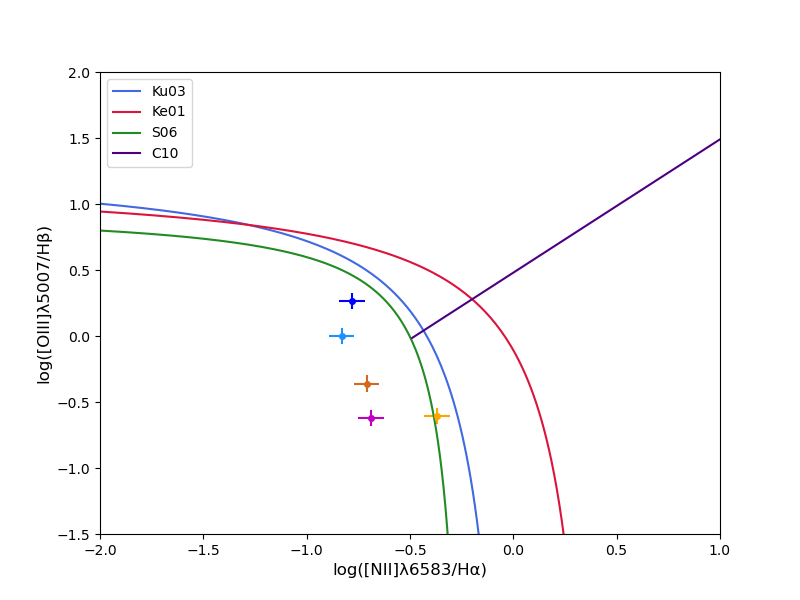

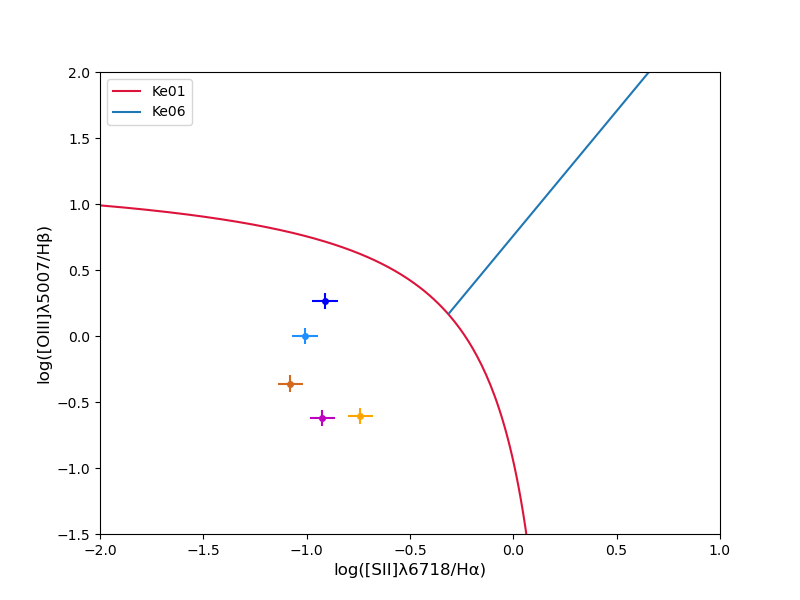

In [46]:
plt.figure(figsize=(8,6))

OIII_HB_1_true, NII_HA_1_true, SII_HA_1_true, err_OIII_HB_1_true, err_SII_HA_1_true, err_NII_HA_1_true = ratio_true(OIII_1, HB_1, HA_1, NII_1, 
                                                                                       SII_1, err_OIII_1, err_HB_1, err_HA_1, err_NII_1, err_SII_1)
#OIII_HB_2_true, NII_HA_2_true, SII_HA_2_true, err_OIII_HB_2_true, err_SII_HA_2_true, err_NII_HA_2_true = ratio_true(OIII_2, HB_2, HA_2, NII_2, 
#                                                                                       SII_2, err_OIII_2, err_HB_2, err_HA_2, err_NII_2, err_SII_2)
OIII_HB_3_true, NII_HA_3_true, SII_HA_3_true, err_OIII_HB_3_true, err_SII_HA_3_true, err_NII_HA_3_true = ratio_true(OIII_3, HB_3, HA_3, NII_3, 
                                                                                       SII_3, err_OIII_3, err_HB_3, err_HA_3, err_NII_3, err_SII_3)
OIII_HB_4_true, NII_HA_4_true, SII_HA_4_true, err_OIII_HB_4_true, err_SII_HA_4_true, err_NII_HA_4_true = ratio_true(OIII_4, HB_4, HA_4, NII_4, 
                                                                                       SII_4, err_OIII_4, err_HB_4, err_HA_4, err_NII_4, err_SII_4)
OIII_HB_5_true, NII_HA_5_true, SII_HA_5_true, err_OIII_HB_5_true, err_SII_HA_5_true, err_NII_HA_5_true = ratio_true(OIII_5, HB_5, HA_5, NII_5, 
                                                                                       SII_5, err_OIII_5, err_HB_5, err_HA_5, err_NII_5, err_SII_5)
OIII_HB_6_true, NII_HA_6_true, SII_HA_6_true, err_OIII_HB_6_true, err_SII_HA_6_true, err_NII_HA_6_true = ratio_true(OIII_6, HB_6, HA_6, NII_6, 
                                                                                       SII_6, err_OIII_6, err_HB_6, err_HA_6, err_NII_6, err_SII_6)

plt.errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_NII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(NII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_NII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
plt.plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
plt.plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
plt.plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
plt.plot(x3, C10(x3), label = 'C10', color = 'indigo')
plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([NII]λ6583/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_1s_true', bbox_inches='tight')

plt.figure(figsize=(8,6))

plt.errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
#plt.errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_SII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
plt.errorbar(x = np.log10(SII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_NII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)

plt.plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
plt.plot(x1, Ke06(x1), label = 'Ke06')

plt.xlim(-2, 1)
plt.ylim(-1.5, 2)
plt.xlabel('log([SII]λ6718/Hα)', fontsize=12)
plt.ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
plt.legend()
plt.savefig('BPT_SII_1s_true', bbox_inches='tight')

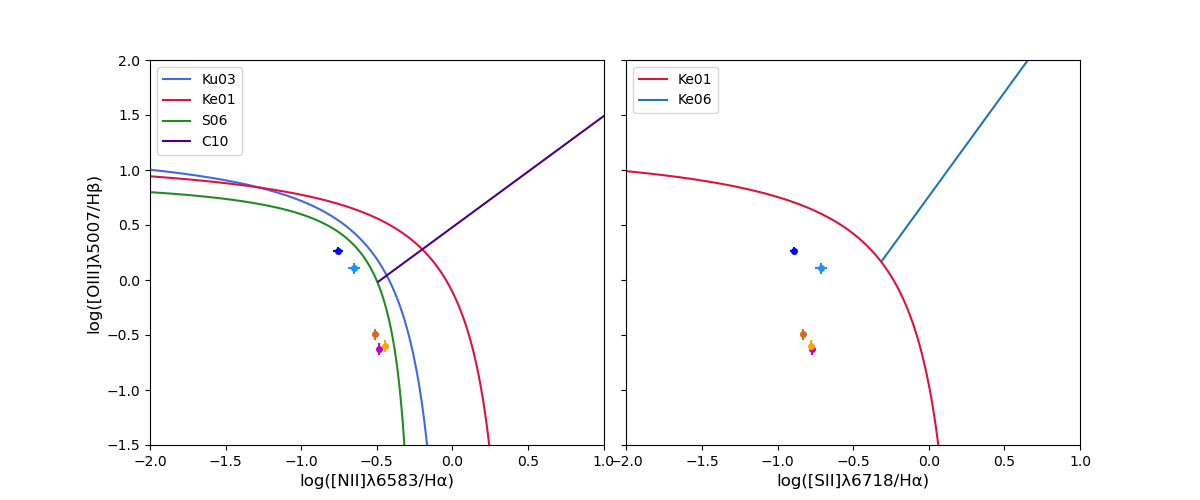

In [47]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_5), y =np.log10(OIII_HB_5), xerr = err_NII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_6), y =np.log10(OIII_HB_6), xerr = err_NII_HA_6, yerr = err_OIII_HB_6,  color = 'dodgerblue', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_4), y = np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_5), y =np.log10(OIII_HB_5), xerr = err_SII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_6), y =np.log10(OIII_HB_6), xerr = err_NII_HA_6, yerr = err_OIII_HB_6,  color = 'dodgerblue', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_1s_both.png', bbox_inches='tight')

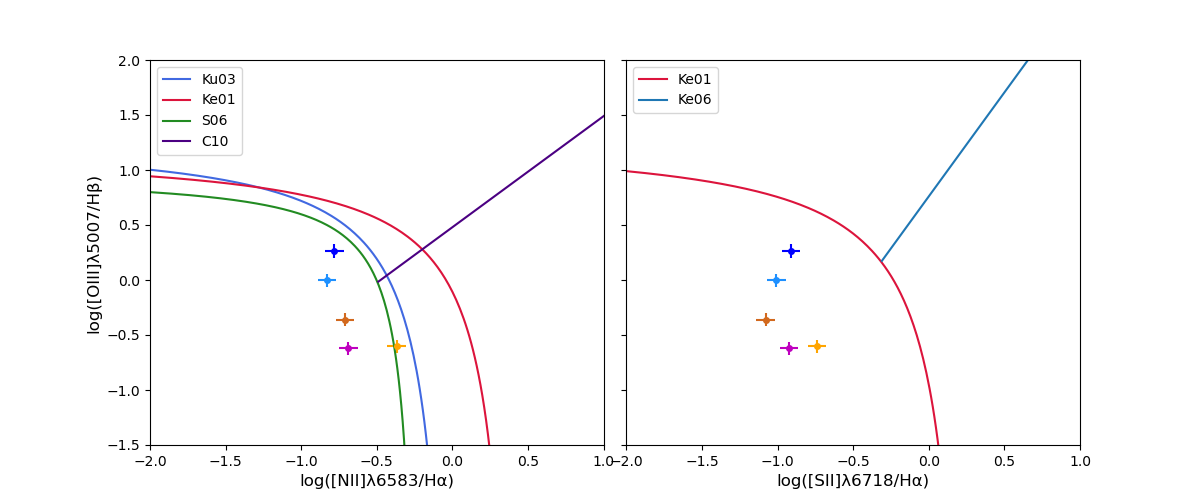

In [48]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_NII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_NII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_SII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_SII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
plt.savefig('BPT_1s_both_true.png', bbox_inches='tight')

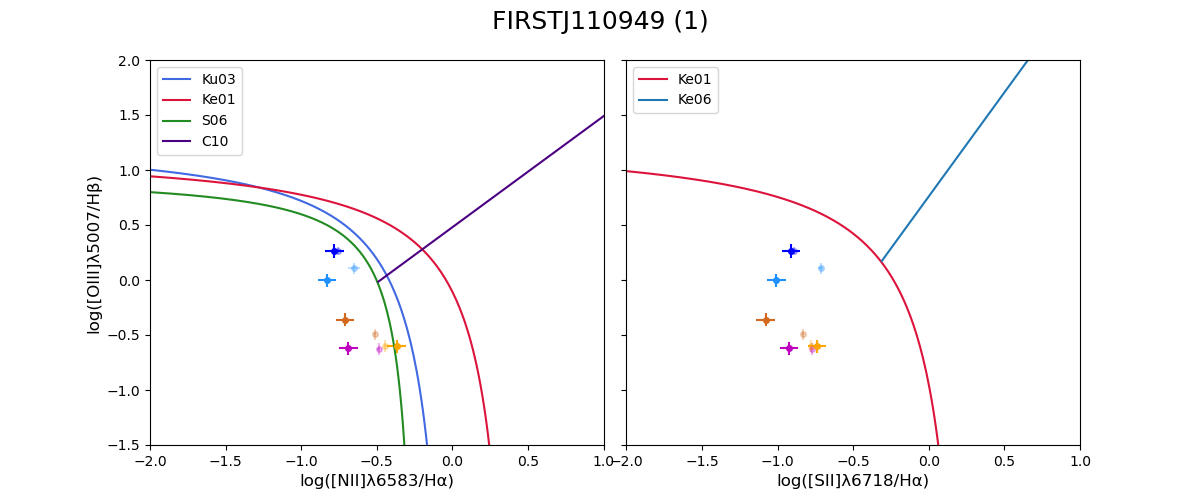

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharey = True)

ax[0].errorbar(x = np.log10(NII_HA_1), y =np.log10(OIII_HB_1), xerr = err_NII_HA_1, yerr = err_OIII_HB_1,  color = 'blue', markersize = 4, marker = 'o', alpha = 0.3)
#ax[0].errorbar(x = np.log10(NII_HA_2), y =np.log10(OIII_HB_2), xerr = err_NII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_3), y =np.log10(OIII_HB_3), xerr = err_NII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_4), y =np.log10(OIII_HB_4), xerr = err_NII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_5), y =np.log10(OIII_HB_5), xerr = err_NII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o', alpha = 0.3)
ax[0].errorbar(x = np.log10(NII_HA_6), y =np.log10(OIII_HB_6), xerr = err_NII_HA_6, yerr = err_OIII_HB_6,  color = 'dodgerblue', markersize = 4, marker = 'o', alpha = 0.3)

ax[0].errorbar(x = np.log10(NII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_NII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
#ax[0].errorbar(x = np.log10(NII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_NII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_NII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_NII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_NII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
ax[0].errorbar(x = np.log10(NII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_NII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.04, num=200)
x1 = np.linspace(-2, 0.457, num=200)
x2 = np.linspace(-2, -0.25, num=200)
x3 = np.linspace(-0.49, 5, num=200)
ax[0].plot(x, Ku03(x), label = 'Ku03', color = 'royalblue')
ax[0].plot(x1, Ke01(x1), label = 'Ke01', color = 'crimson')
ax[0].plot(x2, S06(x2), label = 'S06', color = 'forestgreen')
ax[0].plot(x3, C10(x3), label = 'C10', color = 'indigo')
ax[0].set_xlim(-2, 1)
ax[0].set_ylim(-1.5, 2)
ax[0].set_xlabel('log([NII]λ6583/Hα)', fontsize=12)
ax[0].set_ylabel('log([OIII]λ5007/Hβ)', fontsize=12)
ax[0].legend()

ax[1].errorbar(x = np.log10(SII_HA_1), y = np.log10(OIII_HB_1), xerr = err_SII_HA_1, yerr = err_OIII_HB_1, color = 'blue', markersize = 4, marker = 'o', alpha = 0.3)
#ax[1].errorbar(x = np.log10(SII_HA_2), y = np.log10(OIII_HB_2), xerr = err_SII_HA_2, yerr = err_OIII_HB_2, color = 'green', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_3), y = np.log10(OIII_HB_3), xerr = err_SII_HA_3, yerr = err_OIII_HB_3, color = 'm', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_4), y = np.log10(OIII_HB_4), xerr = err_SII_HA_4, yerr = err_OIII_HB_4, color = 'orange', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_5), y =np.log10(OIII_HB_5), xerr = err_SII_HA_5, yerr = err_OIII_HB_5,  color = 'chocolate', markersize = 4, marker = 'o', alpha = 0.3)
ax[1].errorbar(x = np.log10(SII_HA_6), y =np.log10(OIII_HB_6), xerr = err_SII_HA_6, yerr = err_OIII_HB_6,  color = 'dodgerblue', markersize = 4, marker = 'o', alpha = 0.3)

ax[1].errorbar(x = np.log10(SII_HA_1_true), y = np.log10(OIII_HB_1_true), xerr = err_SII_HA_1_true, yerr = err_OIII_HB_1_true, color = 'blue', markersize = 4, marker = 'o')
#ax[1].errorbar(x = np.log10(SII_HA_2_true), y = np.log10(OIII_HB_2_true), xerr = err_SII_HA_2_true, yerr = err_OIII_HB_2_true, color = 'green', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_3_true), y = np.log10(OIII_HB_3_true), xerr = err_SII_HA_3_true, yerr = err_OIII_HB_3_true, color = 'm', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_4_true), y = np.log10(OIII_HB_4_true), xerr = err_SII_HA_4_true, yerr = err_OIII_HB_4_true, color = 'orange', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_5_true), y = np.log10(OIII_HB_5_true), xerr = err_SII_HA_5_true, yerr = err_OIII_HB_5_true, color = 'chocolate', markersize = 4, marker = 'o')
ax[1].errorbar(x = np.log10(SII_HA_6_true), y = np.log10(OIII_HB_6_true), xerr = err_SII_HA_6_true, yerr = err_OIII_HB_6_true, color = 'dodgerblue', markersize = 4, marker = 'o')

x = np.linspace(-2, 0.1, num=200)
x1 = np.linspace(-0.31, 1, num=200)
ax[1].plot(x, Ke01_SII(x), label = 'Ke01', color = 'crimson')
ax[1].plot(x1, Ke06(x1), label = 'Ke06')
ax[1].set_xlim(-2, 1)
ax[1].set_ylim(-1.5, 2)
ax[1].set_xlabel('log([SII]λ6718/Hα)', fontsize=12)
ax[1].legend()

plt.subplots_adjust(wspace=0.05)
fig.suptitle('FIRSTJ110949 (1)', fontsize=18)
plt.savefig('BPT_1s_motion.png', bbox_inches='tight')